In [1]:
import json
import math
import folium
import networkx as nx
import osmnx as ox
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict
import pathlib

# --- Config ---
DATA_PATH  = "/Volumes/Extreme SSD/SUMO Data/station_information.json"
CSV_2025   = "/Volumes/Extreme SSD/SUMO Data/DonneesOuvertes2025_010203040506070809101112.csv"
CSV_2026   = "/Volumes/Extreme SSD/SUMO Data/DonneesOuvertes2026_01020304.csv"
OUTPUT_DIR = pathlib.Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

## All BIXI stations loaded from station_information.json

In [2]:
with open(DATA_PATH) as f:
    raw = json.load(f)

stations = [
    s for s in raw["data"]["stations"]
    if s["lat"] != 0 and s["lon"] != 0
]

print(f"{len(stations)} valid stations loaded")

1059 valid stations loaded


In [3]:
lats = [s["lat"] for s in stations]
lons = [s["lon"] for s in stations]

bounds = [[min(lats), min(lons)], [max(lats), max(lons)]]

m = folium.Map(tiles="CartoDB positron")
m.fit_bounds(bounds, padding=(24, 24))

for s in stations:
    folium.CircleMarker(
        location=[s["lat"], s["lon"]],
        radius=4,
        color="#e63e2a",
        fill=True,
        fill_color="#e63e2a",
        fill_opacity=0.85,
        weight=1.5,
        tooltip=folium.Tooltip(
            f"<b>{s['name']}</b><br>ID: {s['station_id']}<br>Capacity: {s['capacity']}",
            sticky=False,
        ),
    ).add_to(m)

m

In [4]:
G_bike = ox.graph.graph_from_place("Montreal, Quebec, Canada", network_type="bike")
G_walk = ox.graph.graph_from_place("Montreal, Quebec, Canada", network_type="walk")
G = nx.compose(G_bike, G_walk)


/var/folders/zl/szf1xwds0z98zzqy12bp4q_00000gn/T/ipykernel_64452/49112894.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


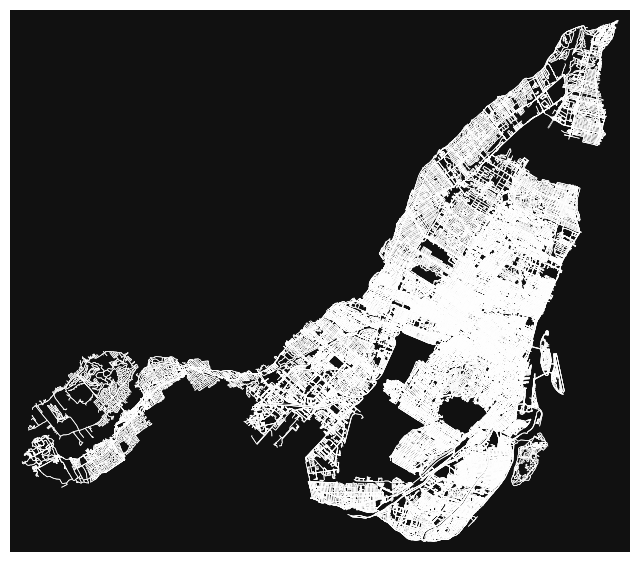

In [5]:
fig, ax = ox.plot.plot_graph(G, node_size=0, edge_color="#FFFFFF", edge_linewidth=0.5, show=False)
fig.show()

#### Shortest path implementation with A*

In [6]:
def shortest_path_Astar(graph, origin, destination, weight="length"):
    """Shortest path using A* algorithm."""
    def heuristic(u, v):
        lu, lv = graph.nodes[u], graph.nodes[v]
        return ox.distance.great_circle(lu['y'], lu['x'], lv['y'],lv['x'])
    try:
        return nx.astar_path(graph, origin, destination, heuristic=heuristic, weight=weight)
    except nx.NetworkXNoPath:
        return None


In [7]:
cols = ["STARTTIMEMS", "STARTSTATIONNAME", "STARTSTATIONLATITUDE", "STARTSTATIONLONGITUDE",
        "ENDSTATIONNAME",   "ENDSTATIONLATITUDE",   "ENDSTATIONLONGITUDE"]

def load_csv(path, chunksize=200_000):
    chunks, total = [], 0
    for chunk in pd.read_csv(path, usecols=cols, chunksize=chunksize, low_memory=False):
        chunk = chunk.dropna()
        total += len(chunk)
        chunks.append(chunk)
    df = pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame(columns=cols)
    return df, total

print("Loading 2025…")
trips, total = load_csv(CSV_2025)
print(f"  {len(trips):,} trips loaded ({total:,} rows processed)")

trips["hour"] = pd.to_datetime(trips["STARTTIMEMS"], unit="ms").dt.hour
print(f"Hours range: {trips['hour'].min()}–{trips['hour'].max()}")

Loading 2025…
  14,197,540 trips loaded (14,197,540 rows processed)
Hours range: 0–23


In [8]:
# Build station → nearest graph node lookup
station_coords = {}
for col_name, col_lat, col_lon in [
    ("STARTSTATIONNAME", "STARTSTATIONLATITUDE", "STARTSTATIONLONGITUDE"),
    ("ENDSTATIONNAME",   "ENDSTATIONLATITUDE",   "ENDSTATIONLONGITUDE"),
]:
    for _, row in trips[[col_name, col_lat, col_lon]].drop_duplicates(col_name).iterrows():
        station_coords[row[col_name]] = (row[col_lat], row[col_lon])

names = list(station_coords)
lats  = [station_coords[n][0] for n in names]
lons  = [station_coords[n][1] for n in names]
nodes = ox.distance.nearest_nodes(G, lons, lats)
station_to_node = dict(zip(names, nodes))

# Map every trip to (src_node, dst_node, hour)
trips["src_node"] = trips["STARTSTATIONNAME"].map(station_to_node)
trips["dst_node"] = trips["ENDSTATIONNAME"].map(station_to_node)
trips = trips.dropna(subset=["src_node", "dst_node"])
trips["src_node"] = trips["src_node"].astype(int)
trips["dst_node"] = trips["dst_node"].astype(int)
trips = trips[trips["src_node"] != trips["dst_node"]]

# Overall unique OD pair counts
pair_counts = (
    trips.groupby(["src_node", "dst_node"]).size()
    .reset_index(name="count")
)
pair_counts = {(r.src_node, r.dst_node): r.count for r in pair_counts.itertuples()}

# Hourly OD pair counts
pair_counts_by_hour = {}
for hour, grp in trips.groupby("hour"):
    hc = grp.groupby(["src_node", "dst_node"]).size().reset_index(name="count")
    pair_counts_by_hour[int(hour)] = {(r.src_node, r.dst_node): r.count for r in hc.itertuples()}

print(f"Unique OD pairs:  {len(pair_counts):,}")
print(f"Hours with data:  {sorted(pair_counts_by_hour.keys())}")

Unique OD pairs:  537,918
Hours with data:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


## A* Shortest Path — Montreal-wide edge load computation

Computes A* once per unique OD pair, caches the edge list, then accumulates both the overall edge load and per-hour edge loads in a single pass.

In [9]:
import time

# --- Step 1: compute A* path for every unique OD pair ---
path_cache = {}   # (src, dst) → list of (u, v) edge tuples
skipped    = set()
t0         = time.perf_counter()
total_pairs = len(pair_counts)

for i, (src, dst) in enumerate(pair_counts):
    if i % 500 == 0:
        print(f"\r{i:,}/{total_pairs:,}  {time.perf_counter()-t0:.0f}s elapsed", end="", flush=True)
    path = shortest_path_Astar(G, src, dst)
    if path is None:
        skipped.add((src, dst))
    else:
        path_cache[(src, dst)] = list(zip(path[:-1], path[1:]))

print(f"\nPaths: {len(path_cache):,} computed | {len(skipped):,} skipped | {time.perf_counter()-t0:.1f}s")

# --- Step 2: overall edge load ---
edge_load = defaultdict(int)
for (src, dst), count in pair_counts.items():
    if (src, dst) in path_cache:
        for u, v in path_cache[(src, dst)]:
            edge_load[(u, v)] += count

# --- Step 3: hourly edge loads ---
edge_load_by_hour = {}
for hour, h_pairs in pair_counts_by_hour.items():
    h_load = defaultdict(int)
    for (src, dst), count in h_pairs.items():
        if (src, dst) in path_cache:
            for u, v in path_cache[(src, dst)]:
                h_load[(u, v)] += count
    edge_load_by_hour[hour] = h_load

print(f"Edge load built: {len(edge_load):,} edges | {len(edge_load_by_hour)} hourly snapshots")

537,500/537,918  21077s elapsed
Paths: 537,918 computed | 0 skipped | 21101.2s
Edge load built: 172,161 edges | 24 hourly snapshots


In [10]:
import pickle, pathlib

_save_path = pathlib.Path("montreal_edge_loads.pkl")
with open(_save_path, "wb") as f:
    pickle.dump({"edge_load": dict(edge_load), "edge_load_by_hour": {h: dict(v) for h, v in edge_load_by_hour.items()}}, f)
print(f"Saved to {_save_path.resolve()}  ({_save_path.stat().st_size / 1e6:.1f} MB)")

Saved to /Users/peterh/Desktop/SUMO Research/montreal_edge_loads.pkl  (69.1 MB)


## Visualization
Run from here the next morning. Either `edge_load` / `edge_load_by_hour` are already in memory, or load them from disk with the cell below.

In [11]:
import pickle
from collections import defaultdict

with open("montreal_edge_loads.pkl", "rb") as f:
    _data = pickle.load(f)

edge_load        = defaultdict(int, _data["edge_load"])
edge_load_by_hour = {h: defaultdict(int, v) for h, v in _data["edge_load_by_hour"].items()}
print(f"Loaded: {len(edge_load):,} edges | {len(edge_load_by_hour)} hourly snapshots")

Loaded: 172,161 edges | 24 hourly snapshots


/var/folders/zl/szf1xwds0z98zzqy12bp4q_00000gn/T/ipykernel_64452/1933786300.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


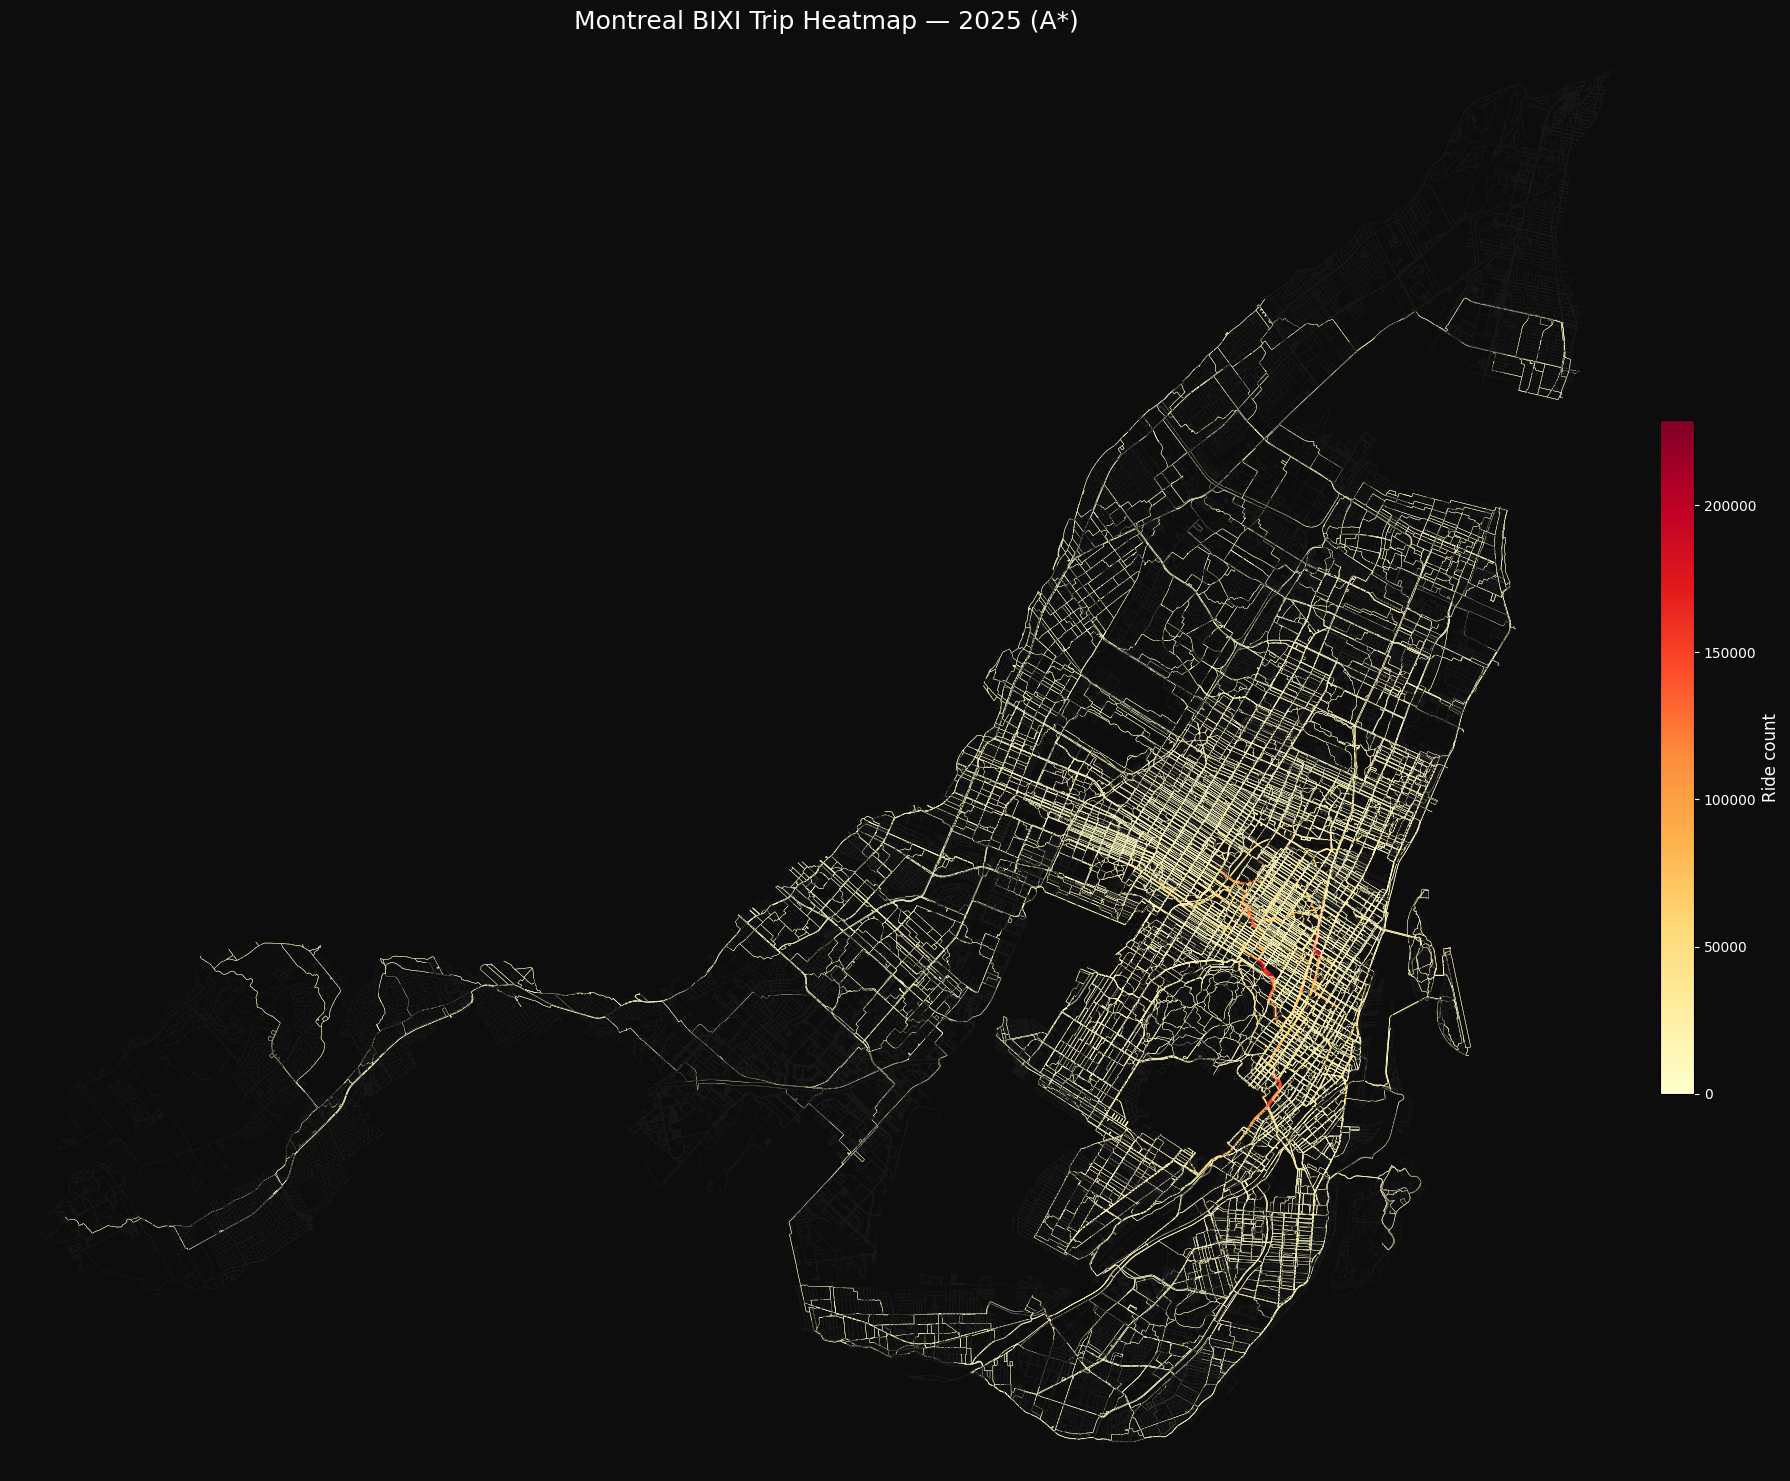

In [12]:
cmap          = plt.cm.YlOrRd
no_load_color = mcolors.to_rgba("#1a1a1a")
global_max    = max(edge_load.values())

edge_colors, edge_widths = [], []
for u, v, _ in G.edges(keys=True):
    load = edge_load.get((u, v), 0)
    norm = load / global_max
    edge_colors.append(cmap(norm) if load > 0 else no_load_color)
    edge_widths.append(0.3 + 3.5 * norm)

fig, ax = plt.subplots(figsize=(18, 18))
fig.patch.set_facecolor("#0d0d0d")
ax.set_facecolor("#0d0d0d")

ox.plot.plot_graph(G, ax=ax, edge_color=edge_colors, edge_linewidth=edge_widths,
                   node_size=0, bgcolor="#0d0d0d", show=False, close=False)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(0, global_max))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.01)
cbar.set_label("Ride count", color="white", fontsize=12)
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

ax.set_title("Montreal BIXI Trip Heatmap — 2025 (A*)", color="white", fontsize=18, pad=10)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "montreal_heatmap.png", dpi=150, bbox_inches="tight", facecolor="#0d0d0d")
fig.show()

## Hourly Flow Breakdown

24-panel grid showing how BIXI traffic distributes across the street network at each hour of the day. Colour scale is shared across all hours so panels are directly comparable.

In [13]:
global_hour_max = max(
    max(h.values(), default=0) for h in edge_load_by_hour.values()
)

for hour in range(24):
    h_load = edge_load_by_hour.get(hour, {})

    edge_colors, edge_widths = [], []
    for u, v, _ in G.edges(keys=True):
        load = h_load.get((u, v), 0)
        norm = load / global_hour_max if global_hour_max > 0 else 0
        edge_colors.append(cmap(norm) if load > 0 else no_load_color)
        edge_widths.append(0.2 + 3.0 * norm)

    fig, ax = plt.subplots(figsize=(18, 18))
    fig.patch.set_facecolor("#0d0d0d")
    ax.set_facecolor("#0d0d0d")

    ox.plot.plot_graph(G, ax=ax, edge_color=edge_colors, edge_linewidth=edge_widths,
                       node_size=0, bgcolor="#0d0d0d", show=False, close=False)
    ax.set_title(f"Montreal BIXI Flow — {hour:02d}:00", color="white", fontsize=18, pad=10)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(0, global_hour_max))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.01)
    cbar.set_label("Ride count", color="white", fontsize=12)
    cbar.ax.yaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

    fig.tight_layout()
    plt.savefig(OUTPUT_DIR / f"montreal_hourly_{hour:02d}.png", dpi=150, bbox_inches="tight", facecolor="#0d0d0d")
    plt.close(fig)
    print(f"Saved {hour:02d}:00")

print("All 24 hourly maps saved.")

Saved 00:00
Saved 01:00
Saved 02:00
Saved 03:00
Saved 04:00
Saved 05:00
Saved 06:00
Saved 07:00
Saved 08:00
Saved 09:00
Saved 10:00
Saved 11:00
Saved 12:00
Saved 13:00
Saved 14:00
Saved 15:00
Saved 16:00
Saved 17:00
Saved 18:00
Saved 19:00
Saved 20:00
Saved 21:00
Saved 22:00
Saved 23:00
All 24 hourly maps saved.


/var/folders/zl/szf1xwds0z98zzqy12bp4q_00000gn/T/ipykernel_64452/2334287901.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


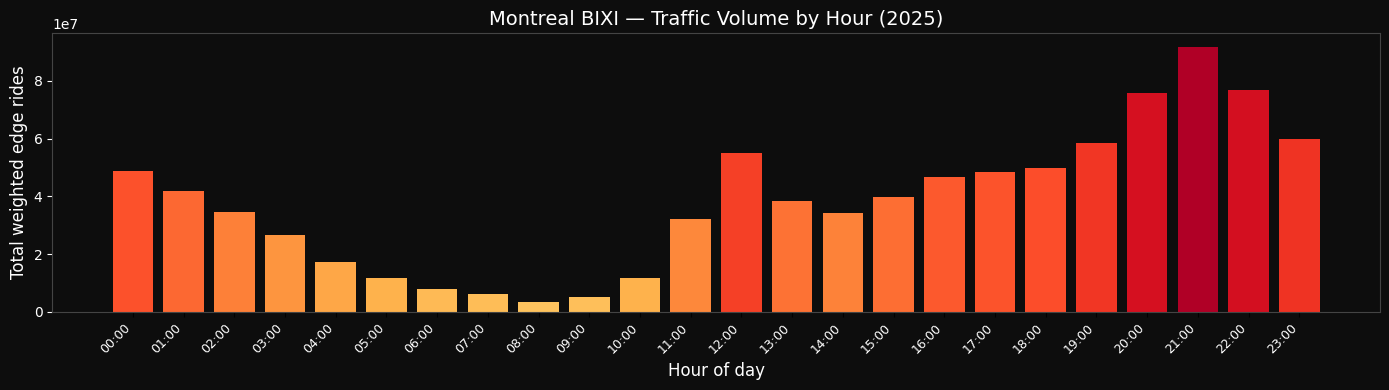

In [14]:
hour_totals = {h: sum(h_load.values()) for h, h_load in edge_load_by_hour.items()}
hours  = sorted(hour_totals)
counts = [hour_totals[h] for h in hours]
colors = [cmap(0.3 + 0.6 * (c / max(counts))) for c in counts]

fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor("#0d0d0d")
ax.set_facecolor("#0d0d0d")

ax.bar(hours, counts, color=colors, width=0.8)
ax.set_xlabel("Hour of day", color="white", fontsize=12)
ax.set_ylabel("Total weighted edge rides", color="white", fontsize=12)
ax.set_title("Montreal BIXI — Traffic Volume by Hour (2025)", color="white", fontsize=14)
ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45, ha="right", color="white", fontsize=9)
ax.tick_params(axis="y", colors="white")
for spine in ax.spines.values():
    spine.set_edgecolor("#444")

fig.tight_layout()
plt.savefig(OUTPUT_DIR / "montreal_hourly_bar.png", dpi=150, bbox_inches="tight", facecolor="#0d0d0d")
fig.show()